## SVM Kernels Implementation

In [67]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(12**2 - x**2)
y = np.hstack([y,-y])
x = np.hstack([x,-x])

In [68]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

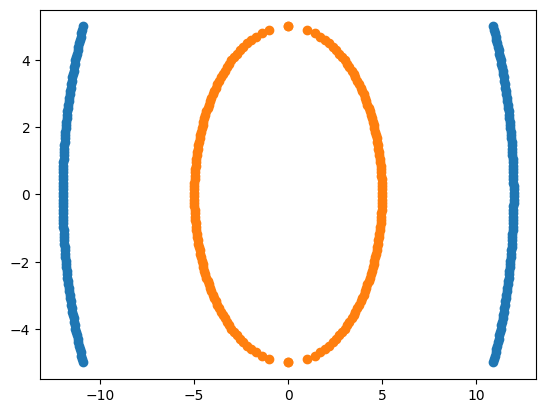

In [69]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [70]:
import pandas as pd
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,10.908712,-5.00000,0
1,10.954446,-4.89899,0
2,10.999063,-4.79798,0
3,11.042576,-4.69697,0
4,11.084997,-4.59596,0


In [71]:
## Independent and Dependent Features
X = df.iloc[:,:2]
y = df.Y

In [72]:
X,y

(            X1       X2
 0    10.908712 -5.00000
 1    10.954446 -4.89899
 2    10.999063 -4.79798
 3    11.042576 -4.69697
 4    11.084997 -4.59596
 ..         ...      ...
 395  -1.969049 -4.59596
 396  -1.714198 -4.69697
 397  -1.406908 -4.79798
 398  -0.999949 -4.89899
 399  -0.000000 -5.00000
 
 [400 rows x 2 columns],
 0      0
 1      0
 2      0
 3      0
 4      0
       ..
 395    1
 396    1
 397    1
 398    1
 399    1
 Name: Y, Length: 400, dtype: int64)

In [73]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [74]:
# We need to find components for the Polynomial Kernal
# X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']= df['X1']**2
df['X2_Square']= df['X2']**2
df['X1*X2']= df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,10.908712,-5.00000,0,119.000000,25.000000,-54.543561
1,10.954446,-4.89899,0,119.999898,24.000102,-53.665723
2,10.999063,-4.79798,0,120.979390,23.020610,-52.773283
3,11.042576,-4.69697,0,121.938476,22.061524,-51.866643
4,11.084997,-4.59596,0,122.877155,21.122845,-50.946198


In [75]:
## Independent and Dependent Features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [76]:
X,y

(            X1       X2   X1_Square  X2_Square      X1*X2
 0    10.908712 -5.00000  119.000000  25.000000 -54.543561
 1    10.954446 -4.89899  119.999898  24.000102 -53.665723
 2    10.999063 -4.79798  120.979390  23.020610 -52.773283
 3    11.042576 -4.69697  121.938476  22.061524 -51.866643
 4    11.084997 -4.59596  122.877155  21.122845 -50.946198
 ..         ...      ...         ...        ...        ...
 395  -1.969049 -4.59596    3.877155  21.122845   9.049671
 396  -1.714198 -4.69697    2.938476  22.061524   8.051537
 397  -1.406908 -4.79798    1.979390  23.020610   6.750316
 398  -0.999949 -4.89899    0.999898  24.000102   4.898740
 399  -0.000000 -5.00000    0.000000  25.000000   0.000000
 
 [400 rows x 5 columns],
 0      0
 1      0
 2      0
 3      0
 4      0
       ..
 395    1
 396    1
 397    1
 398    1
 399    1
 Name: Y, Length: 400, dtype: int64)

In [77]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [78]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,11.922269,1.363636,142.140496,1.859504,16.257639
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-11.961571,-0.959596,143.079176,0.920824,11.478275
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-11.205836,-4.292929,125.570758,18.429242,48.105861
117,-11.542228,3.282828,133.223038,10.776962,-37.891154
47,11.997343,-0.252525,143.936231,0.063769,-3.029632


In [79]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [80]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1',y='X2', z='X1*X2',color='Y')

fig.show()

In [81]:
fig = px.scatter_3d(df, x='X1_Square',y='X2_Square', z='X1*X2',color='Y')

fig.show()

## Support Vector Machine (SVM) Kernel Functions

The Kernel Trick is a fundamental concept in SVMs that allows them to find non-linear decision boundaries by implicitly mapping data into a high-dimensional feature space. The kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ calculates the dot product in this new space.

### 1. Linear Kernel

This is the simplest kernel. It is equivalent to running a standard linear classification (no trick needed) and is used when the data is already linearly separable.

Formula (in LaTeX)

$$K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$$

Variable Definitions

$\mathbf{x}_i$: The feature vector of the $i^{th}$ data point.

$\mathbf{x}_j$: The feature vector of the $j^{th}$ data point.

$\mathbf{x}_i^T \mathbf{x}_j$: The dot product of the two vectors.

### 2. Polynomial Kernel

This kernel is effective for data that can be separated by a curved boundary (like a parabola or a circle). It maps the data into a feature space defined by the polynomial degree.

Formula (in LaTeX)

$$K(\mathbf{x}_i, \mathbf{x}_j) = (\alpha \mathbf{x}_i^T \mathbf{x}_j + r)^d$$

Parameter Definitions

$d$: The degree of the polynomial. Higher degrees lead to more complex boundaries and a risk of overfitting.

$\alpha$: A scaling parameter (often set to 1).

$r$: An independent term or offset (often set to 0 or 1).

### 3. Radial Basis Function (RBF) Kernel (Gaussian Kernel)

The RBF is the most widely used kernel. It implicitly maps the data into an infinite-dimensional space and is highly effective for complex, non-linear relationships.

Formula (in LaTeX)

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma ||\mathbf{x}_i - \mathbf{x}_j||^2)$$

Parameter Definitions

$\gamma$ (gamma): Controls the influence of a single training example. A smaller $\gamma$ means a wider, smoother decision boundary, while a larger $\gamma$ means a tighter boundary, potentially leading to overfitting.

$||\mathbf{x}_i - \mathbf{x}_j||^2$: The squared Euclidean distance between the two data points.

### 4. Sigmoid Kernel

This kernel is related to the activation function used in Neural Networks (the hyperbolic tangent function).

Formula (in LaTeX)

$$K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\alpha \mathbf{x}_i^T \mathbf{x}_j + r)$$

Parameter Definitions

$\alpha$: A slope parameter.

$r$: An intercept term.

In [82]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier= SVC(kernel='linear')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [83]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier= SVC(kernel='poly')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [84]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier= SVC(kernel='rbf')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [85]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier= SVC(kernel='sigmoid')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0